# 10. Odds, log-odds, odds ratio, Fisher, chi-square i Wald bez `statsmodels`

Ten notebook jest uporządkowaną wersją materiału o probability, odds, log-odds i testach dla tabeli 2×2. Nie używa `statsmodels`; regresję logistyczną dla tabeli 2×2 dopasujemy ręcznie metodą Newtona/IRLS.

Główna ścieżka dydaktyczna:

1. `p_prob` to prawdopodobieństwo zdarzenia.
2. `odds` to stosunek „sukcesów” do „porażek”.
3. `log(odds)` zamienia zakres $(0,\infty)$ na $(-\infty,\infty)$.
4. `odds ratio` porównuje odds między dwiema grupami.
5. `log(odds ratio)` jest współczynnikiem w prostej regresji logistycznej z predyktorem 0/1.
6. Fisher, chi-square i Wald to trzy różne sposoby testowania związku w tabeli 2×2.

Uwaga na oznaczenia: w pierwszych sekcjach `p_prob` oznacza **prawdopodobieństwo**, a w częściach o testach `p_value` oznacza **wynik testu statystycznego**.


In [1]:
import math
from math import comb, log, exp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import hypergeom, chi2, norm, fisher_exact, chi2_contingency

pd.set_option('display.precision', 6)

## 1. Prawdopodobieństwo, odds i log-odds

Prawdopodobieństwo zdarzenia zapisujemy tutaj jako `p_prob`, żeby nie mylić go później z `p_value` testu statystycznego.

Prawdopodobieństwo:

$$
0 \le p_{prob} \le 1
$$

Odds:

$$
odds = \frac{p_{prob}}{1-p_{prob}}
$$

Odwrotne przejście:

$$
p_{prob} = \frac{odds}{1+odds}
$$

Log-odds, czyli logit:

$$
logit(p_{prob}) = \log\left(\frac{p_{prob}}{1-p_{prob}}\right)
$$

Dlaczego logit jest wygodny? Bo $p_{prob}$ żyje w przedziale $[0,1]$, ale $logit(p_{prob})$ żyje na całej osi rzeczywistej. Dzięki temu możemy modelować go liniowo:

$$
logit(p_{prob}) = X\beta
$$


### Jak czytać odds zapisane jako `2:3` albo `3:5`?

Zapis odds `a:b` oznacza:

$$
odds=\frac{a}{b}
$$

czyli stosunek **sukcesów do porażek**.

To nie jest to samo co prawdopodobieństwo. Jeśli odds wynosi `a:b`, to:

$$
p_{prob}=\frac{a}{a+b}
$$

Dwa przykłady:

- odds `2:3` oznacza odds $2/3$, ale prawdopodobieństwo $2/(2+3)=2/5=0.4$,
- odds `3:5` oznacza odds $3/5$, ale prawdopodobieństwo $3/(3+5)=3/8=0.375$.


In [2]:
odds_examples = pd.DataFrame({
    'odds zapisane jako': ['2:3', '3:5'],
    'sukcesy a': [2, 3],
    'porażki b': [3, 5],
})

odds_examples['odds = a/b'] = odds_examples['sukcesy a'] / odds_examples['porażki b']
odds_examples['p_prob = a/(a+b)'] = odds_examples['sukcesy a'] / (odds_examples['sukcesy a'] + odds_examples['porażki b'])
odds_examples['log_odds = log(a/b)'] = np.log(odds_examples['odds = a/b'])

odds_examples

,odds zapisane jako,sukcesy a,porażki b,odds = a/b,p_prob = a/(a+b),log_odds = log(a/b)
0,2:3,2,3,0.666667,0.400,-0.405465
1,3:5,3,5,0.600000,0.375,-0.510826


### Intuicja: liczba sukcesów i porażek

Załóżmy:

- liczba sukcesów: $N_{+}$,
- liczba porażek: $N_{-}$.

Wtedy prawdopodobieństwo sukcesu to:

$$
p_{prob} = \frac{N_{+}}{N_{+}+N_{-}}
$$

Odds jako stosunek sukcesów do porażek:

$$
\mathrm{odds} = \frac{N_{+}}{N_{-}}
$$

czyli:

- odds $>1$ → sukces bardziej prawdopodobny niż porażka,
- odds $=1$ → sytuacja 50/50,
- odds $<1$ → porażka bardziej prawdopodobna niż sukces.

Przykład:

- $N_{+}=80$,
- $N_{-}=20$.

Wtedy:

$$
p_{prob}=\frac{80}{80+20}=0.8
$$

oraz:

$$
\mathrm{odds}=\frac{80}{20}=4
$$

Odwrotnie, jeśli odds wynosi 4, to:

$$
p_{prob}=\frac{4}{1+4}=\frac{4}{5}=0.8
$$

Probability mówi: „jaka część wszystkich przypadków to sukces?”.

Odds mówi: „ile sukcesów przypada na jedną porażkę?”.


Dla:

$$
p=\frac{4}{5}=0.8
$$

mamy:

$$
1-p=\frac{1}{5}=0.2
$$

więc odds to:

$$
\mathrm{odds}=\frac{p}{1-p}
=\frac{\frac{4}{5}}{\frac{1}{5}}
=\frac{4}{1}
$$

Jeśli odds wynosi $4$, to:

$$
p=\frac{4}{1+4}=\frac{4}{5}=0.8
$$

A sprawdzając w drugą stronę:

$$
\mathrm{odds}
=
\frac{p}{1-p}
=
\frac{\frac{4}{5}}{\frac{1}{5}}
=
4
$$

### Krótkie ćwiczenie dla studentów:

### Ćwiczenie: probability, odds i odds ratio

Uzupełnij brakujące wartości.

| Grupa | $N_{+}$ | $N_{-}$ | $p$ | odds |
|---|---:|---:|---:|---:|
| A | 30 | 10 | ? | ? |
| B | 20 | 20 | ? | ? |

1. Policz prawdopodobieństwo sukcesu w grupie A:

$$
p_A = \frac{N_+}{N_+ + N_-}
$$

2. Policz odds w grupie A:

$$
\mathrm{odds}_A = \frac{N_+}{N_-}
$$

3. Policz prawdopodobieństwo sukcesu w grupie B.

4. Policz odds w grupie B.

5. Policz odds ratio:

$$
OR = \frac{\mathrm{odds}_A}{\mathrm{odds}_B}
$$

6. Zinterpretuj wynik jednym zdaniem.

### Odpowiedź

Grupa A:

$$
p_A = \frac{30}{30+10}=\frac{30}{40}=0.75
$$

$$
\mathrm{odds}_A=\frac{30}{10}=3
$$

Grupa B:

$$
p_B = \frac{20}{20+20}=\frac{20}{40}=0.5
$$

$$
\mathrm{odds}_B=\frac{20}{20}=1
$$

Odds ratio:

$$
OR=\frac{3}{1}=3
$$

Interpretacja:

> Odds sukcesu w grupie A są 3 razy większe niż odds sukcesu w grupie B.


### Intuicja sportowa: słaba i dobra drużyna

Odds można rozumieć jako proporcję:

$$
\text{sukces} : \text{porażka}
$$

czyli np. szansa wygranej drużyny względem szansy przegranej.

---

### Słaba drużyna

$$
\mathrm{odds}=\frac{1}{1}
$$

to znaczy, że proporcja wygrana : przegrana wynosi:

$$
1:1
$$


$$
\mathrm{odds}=\frac{1}{2}
$$

to znaczy, że proporcja wygrana : przegrana wynosi:

$$
1:2
$$
Jeśli słaba drużyna ma odds:

$$
\mathrm{odds}=\frac{1}{32}
$$

to znaczy, że proporcja wygrana : przegrana wynosi:

$$
1:32
$$

Czyli na łącznie $1+32=33$ części tylko jedna odpowiada wygranej.

Prawdopodobieństwo wygranej:

$$
p=\frac{1}{1+32}=\frac{1}{33}\approx 0.030
$$

czyli około $3.0\%$.

Jeszcze słabsza drużyna:

$$
\mathrm{odds}=\frac{1}{64}
$$

oznacza proporcję:

$$
1:64
$$

więc:

$$
p=\frac{1}{1+64}=\frac{1}{65}\approx 0.015
$$

czyli około $1.5\%$.

---

### Dobra drużyna

Jeśli dobra drużyna ma odds:

$$
\mathrm{odds}=\frac{2}{1}
$$

to znaczy, że proporcja wygrana : przegrana wynosi:

$$
2:1
$$

czyli:

$$
p=\frac{2}{2+1}=\frac{2}{3}\approx 0.667
$$

czyli około $66.7\%$.

Jeśli drużyna ma odds:

$$
\mathrm{odds}=\frac{5}{1}
$$

to:

$$
p=\frac{5}{5+1}=\frac{5}{6}\approx 0.833
$$

czyli około $83.3\%$.

Bardzo silna drużyna:

$$
\mathrm{odds}=\frac{100}{1}
$$

oznacza:

$$
100:1
$$

więc:

$$
p=\frac{100}{100+1}=\frac{100}{101}\approx 0.990
$$

czyli około $99.0\%$.

---

### Wniosek

Odds mniejsze niż $1$ oznaczają, że sukces jest mniej prawdopodobny niż porażka.

Odds równe $1$ oznaczają sytuację $50/50$.

Odds większe niż $1$ oznaczają, że sukces jest bardziej prawdopodobny niż porażka.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.precision", 4)

odds_values = np.array([
    1/64, 1/32, 1/16, 1/8, 1/4, 1/2,
    1,
    2, 5, 10, 20, 50, 100
])

df_odds = pd.DataFrame({
    "odds": odds_values,
})

df_odds["p"] = df_odds["odds"] / (1 + df_odds["odds"])
df_odds["1-p"] = 1 - df_odds["p"]
df_odds["log_odds"] = np.log(df_odds["odds"])

df_odds

,odds,p,1-p,log_odds
0,0.0156,0.0154,0.9846,-4.1589
1,0.0312,0.0303,0.9697,-3.4657
2,0.0625,0.0588,0.9412,-2.7726
3,0.1250,0.1111,0.8889,-2.0794
4,0.2500,0.2000,0.8000,-1.3863
5,0.5000,0.3333,0.6667,-0.6931
6,1.0000,0.5000,0.5000,0.0000
7,2.0000,0.6667,0.3333,0.6931
8,5.0000,0.8333,0.1667,1.6094
9,10.0000,0.9091,0.0909,2.3026


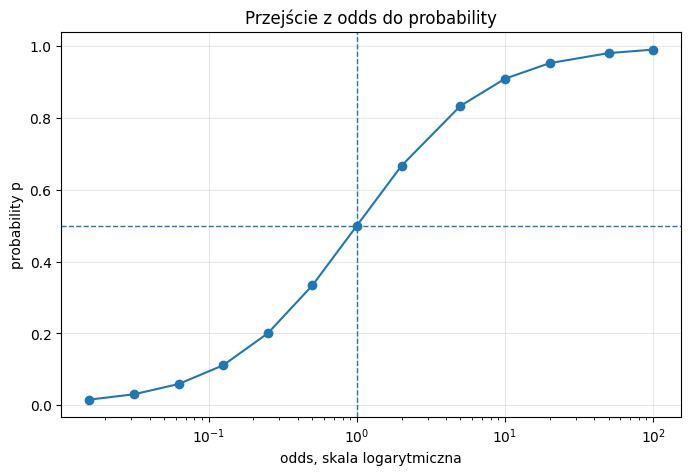

In [4]:
plt.figure(figsize=(8, 5))

plt.plot(df_odds["odds"], df_odds["p"], marker="o")

plt.xscale("log")
plt.axhline(0.5, linestyle="--", linewidth=1)
plt.axvline(1, linestyle="--", linewidth=1)

plt.xlabel("odds, skala logarytmiczna")
plt.ylabel("probability p")
plt.title("Przejście z odds do probability")

plt.grid(True, alpha=0.3)
plt.show()

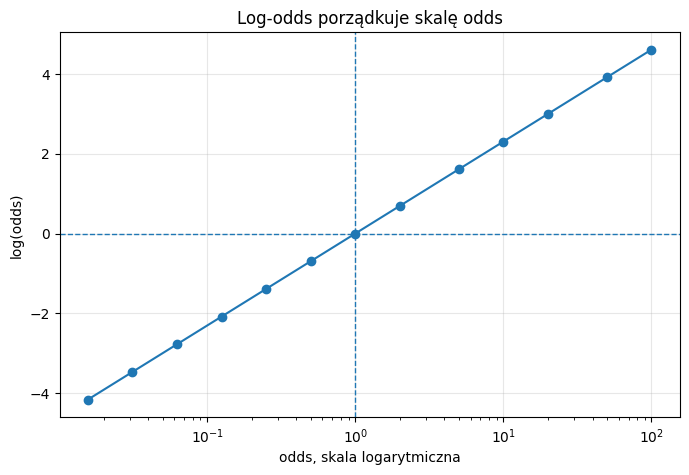

In [5]:
plt.figure(figsize=(8, 5))

plt.plot(df_odds["odds"], df_odds["log_odds"], marker="o")

plt.xscale("log")
plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(1, linestyle="--", linewidth=1)

plt.xlabel("odds, skala logarytmiczna")
plt.ylabel("log(odds)")
plt.title("Log-odds porządkuje skalę odds")

plt.grid(True, alpha=0.3)
plt.show()

---

### Odds ratio

Odds ratio porównuje odds w dwóch grupach.

Załóżmy teraz dwie grupy:

| Grupa | $N_{+}$ | $N_{-}$ | $p$ | odds |
|---|---:|---:|---:|---:|
| A | 80 | 20 | $0.8$ | $4$ |
| B | 50 | 50 | $0.5$ | $1$ |

W grupie A:

$$
\mathrm{odds}_A = \frac{80}{20}=4
$$

W grupie B:

$$
\mathrm{odds}_B = \frac{50}{50}=1
$$

Odds ratio:

$$
OR = \frac{\mathrm{odds}_A}{\mathrm{odds}_B}
$$

czyli:

$$
OR = \frac{4}{1}=4
$$

Interpretacja:

> Odds sukcesu w grupie A są 4 razy większe niż odds sukcesu w grupie B.

Uwaga: to nie znaczy, że prawdopodobieństwo jest 4 razy większe.  
Prawdopodobieństwa wynoszą:

$$
p_A=0.8
$$

$$
p_B=0.5
$$

czyli stosunek prawdopodobieństw to:

$$
\frac{p_A}{p_B}=\frac{0.8}{0.5}=1.6
$$

Dlatego odds ratio i ratio prawdopodobieństw to nie to samo.

In [6]:
probabilities = np.array([0.01, 0.05, 0.10, 0.20, 0.50, 0.80, 0.90, 0.95, 0.99])
odds = probabilities / (1 - probabilities)
log_odds = np.log(odds)

pd.DataFrame({
    'p': probabilities,
    'odds = p/(1-p)': odds,
    'log_odds = log(odds)': log_odds,
})

,p,odds = p/(1-p),log_odds = log(odds)
0,0.01,0.0101,-4.5951
1,0.05,0.0526,-2.9444
2,0.10,0.1111,-2.1972
3,0.20,0.2500,-1.3863
4,0.50,1.0000,0.0000
5,0.80,4.0000,1.3863
6,0.90,9.0000,2.1972
7,0.95,19.0000,2.9444
8,0.99,99.0000,4.5951


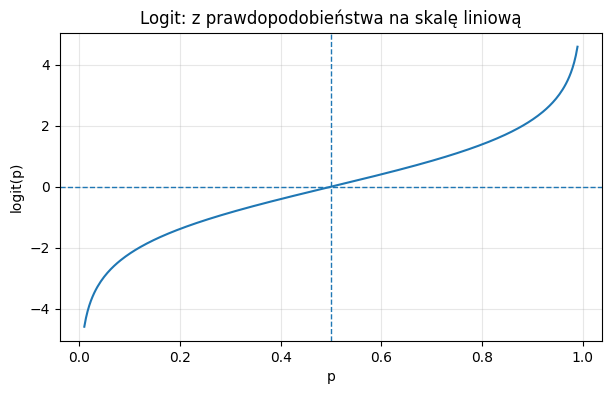

In [7]:
p_grid = np.linspace(0.01, 0.99, 300)
logit_grid = np.log(p_grid / (1 - p_grid))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(p_grid, logit_grid)
ax.axhline(0, linewidth=1, linestyle='--')
ax.axvline(0.5, linewidth=1, linestyle='--')
ax.set_xlabel('p')
ax.set_ylabel('logit(p)')
ax.set_title('Logit: z prawdopodobieństwa na skalę liniową')
ax.grid(True, alpha=0.3)
plt.show()

## 2. Odds ratio dla tabeli 2×2

Użyjemy klasycznej małej tabeli:

$$
\begin{array}{c|cc}
 & Cancer=Yes & Cancer=No \\
\hline
Mutated=Yes & a & b \\
Mutated=No & c & d
\end{array}
$$

W każdym wierszu traktujemy `Cancer=Yes` jako „sukces”, a `Cancer=No` jako „porażkę”.

Dla grupy `Mutated=Yes`:

$$
p_{prob, mutated}=\frac{a}{a+b}
$$

$$
odds_{mutated} = \frac{a}{b}
$$

Dla grupy `Mutated=No`:

$$
p_{prob, not\ mutated}=\frac{c}{c+d}
$$

$$
odds_{not\ mutated} = \frac{c}{d}
$$

Odds ratio:

$$
OR = \frac{a/b}{c/d}=\frac{ad}{bc}
$$

oraz:

$$
\log(OR)=\log\left(\frac{ad}{bc}\right)
$$


In [8]:
obs = np.array([[23, 117],
                [ 6, 210]])
counts = pd.DataFrame(obs,
                      index=['Mutated gene: Yes', 'Mutated gene: No'],
                      columns=['Cancer: Yes', 'Cancer: No'])
counts

,Cancer: Yes,Cancer: No
Mutated gene: Yes,23,117
Mutated gene: No,6,210


In [9]:
group_summary = counts.copy()
group_summary['row_total'] = group_summary.sum(axis=1)
group_summary['p_prob(Cancer=Yes)'] = group_summary['Cancer: Yes'] / group_summary['row_total']
group_summary['odds(Cancer=Yes) = Yes/No'] = group_summary['Cancer: Yes'] / group_summary['Cancer: No']
group_summary['log_odds(Cancer=Yes)'] = np.log(group_summary['odds(Cancer=Yes) = Yes/No'])

group_summary

,Cancer: Yes,Cancer: No,row_total,p_prob(Cancer=Yes),odds(Cancer=Yes) = Yes/No,log_odds(Cancer=Yes)
Mutated gene: Yes,23,117,140,0.1643,0.1966,-1.6267
Mutated gene: No,6,210,216,0.0278,0.0286,-3.5553


In [10]:
a, b, c, d = obs.ravel()
odds_mutated = a / b
odds_not_mutated = c / d
odds_ratio = (a*d) / (b*c)
log_odds_ratio = math.log(odds_ratio)

pd.Series({
    'odds_mutated = 23/117': odds_mutated,
    'odds_not_mutated = 6/210': odds_not_mutated,
    'OR = (23*210)/(117*6)': odds_ratio,
    'log(OR)': log_odds_ratio,
})

odds_mutated = 23/117       0.1966
odds_not_mutated = 6/210    0.0286
OR = (23*210)/(117*6)       6.8803
log(OR)                     1.9287
dtype: float64

Interpretacja:

- $OR=1$: brak różnicy odds między grupami,
- $OR>1$: odds są większe w grupie `Mutated=Yes`,
- $OR<1$: odds są mniejsze w grupie `Mutated=Yes`,
- $\log(OR)=0$: brak różnicy,
- dodatni $\log(OR)$: większe odds w pierwszej grupie,
- ujemny $\log(OR)$: mniejsze odds w pierwszej grupie.

## 3. Test Fishera ręcznie

Od tego miejsca `p_value` oznacza **p-value testu statystycznego**, a nie prawdopodobieństwo zdarzenia z sekcji 1.

Test Fishera zakłada ustalone sumy brzegowe. Pod hipotezą zerową liczba przypadków `Cancer=Yes` w grupie `Mutated=Yes` ma rozkład hipergeometryczny.

Dla tabeli:

$$
\begin{array}{c|cc|c}
 & Cancer=Yes & Cancer=No & row\ sum \\
\hline
Mutated=Yes & a & b & a+b \\
Mutated=No & c & d & c+d \\
\hline
col\ sum & a+c & b+d & n
\end{array}
$$

Jeśli $X$ oznacza liczbę przypadków `Cancer=Yes` w pierwszym wierszu, to:

$$
X \sim Hypergeometric(N, K, n_1)
$$

gdzie:

- $N$ to łączna liczba obserwacji,
- $K$ to liczba wszystkich przypadków `Cancer=Yes`,
- $n_1$ to liczba obserwacji w grupie `Mutated=Yes`.


In [11]:
row_sums = obs.sum(axis=1)
col_sums = obs.sum(axis=0)
N_total = obs.sum()
K_successes = col_sums[0]
n_draws = row_sums[0]
observed_x = obs[0, 0]

x_min = max(0, n_draws - col_sums[1])
x_max = min(n_draws, K_successes)
xs = np.arange(x_min, x_max + 1)
pmfs = hypergeom.pmf(xs, N_total, K_successes, n_draws)

fisher_table = pd.DataFrame({'x = Cancer Yes in Mutated group': xs, 'probability under H0': pmfs})
fisher_table.loc[fisher_table['x = Cancer Yes in Mutated group'].between(observed_x-3, observed_x+3)]

,x = Cancer Yes in Mutated group,probability under H0
20,20,5.7295e-04
21,21,1.4166e-04
22,22,2.9331e-05
23,23,5.0160e-06
24,24,6.9534e-07
25,25,7.6094e-08
26,26,6.3206e-09


In [12]:
prob_observed_table = hypergeom.pmf(observed_x, N_total, K_successes, n_draws)
p_value_left = hypergeom.cdf(observed_x, N_total, K_successes, n_draws)
p_value_right = hypergeom.sf(observed_x - 1, N_total, K_successes, n_draws)
p_value_two_sided = pmfs[pmfs <= prob_observed_table + 1e-15].sum()

scipy_or, scipy_fisher_pvalue = fisher_exact(obs, alternative='two-sided')

pd.Series({
    'observed_x': observed_x,
    'P(observed table under H0)': prob_observed_table,
    'p_value_left = P(X <= observed)': p_value_left,
    'p_value_right = P(X >= observed)': p_value_right,
    'p_value_two_sided_manual': p_value_two_sided,
    'scipy_fisher_two_sided_p_value': scipy_fisher_pvalue,
})

observed_x                          2.3000e+01
P(observed table under H0)          5.0160e-06
p_value_left = P(X <= observed)     1.0000e+00
p_value_right = P(X >= observed)    5.7941e-06
p_value_two_sided_manual            1.0987e-05
scipy_fisher_two_sided_p_value      1.0987e-05
dtype: float64

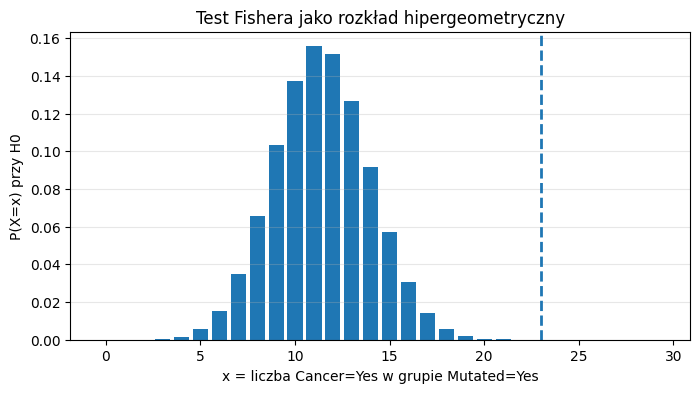

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(xs, pmfs)
ax.axvline(observed_x, linestyle='--', linewidth=2)
ax.set_xlabel('x = liczba Cancer=Yes w grupie Mutated=Yes')
ax.set_ylabel('P(X=x) przy H0')
ax.set_title('Test Fishera jako rozkład hipergeometryczny')
ax.grid(True, axis='y', alpha=0.3)
plt.show()

## 4. Test chi-square ręcznie — dokładnie na przykładzie ze zrzutu

Na zrzucie mamy taką tabelę obserwowanych liczebności:

$$
\begin{array}{c|cc|c}
 & \text{Cancer=Yes} & \text{Cancer=No} & \text{razem} \\
\hline
\text{Mutated gene=Yes} & 23 & 117 & 140 \\
\text{Mutated gene=No} & 6 & 210 & 216 \\
\hline
\text{razem} & 29 & 327 & 356
\end{array}
$$

Na zrzucie pojawia się też:

$$
p_{prob}(\text{Cancer})=\frac{29}{356}\approx 0.081
$$

To jest **zwykłe prawdopodobieństwo raka w całej próbie**. To **nie jest** jeszcze `p-value` testu statystycznego.

Test chi-square zadaje inne pytanie:

> Czy `Has mutated gene` i `Has cancer` wyglądają na niezależne?

Hipotezy:

- $H_0$: mutacja genu i rak są niezależne,
- $H_1$: mutacja genu i rak nie są niezależne, czyli istnieje związek statystyczny.


In [14]:
# Tabela ze zrzutu
obs = np.array([[23, 117],
                [ 6, 210]])

counts = pd.DataFrame(obs,
                      index=['Mutated gene: Yes', 'Mutated gene: No'],
                      columns=['Cancer: Yes', 'Cancer: No'])

# Dodajemy sumy brzegowe, żeby było tak jak na tablicy 2x2.
counts_with_totals = counts.copy()
counts_with_totals['row_total'] = counts_with_totals.sum(axis=1)
counts_with_totals.loc['column_total'] = counts_with_totals.sum(axis=0)
counts_with_totals

,Cancer: Yes,Cancer: No,row_total
Mutated gene: Yes,23,117,140
Mutated gene: No,6,210,216
column_total,29,327,356


### Krok 1. Liczymy ogólne prawdopodobieństwo raka

W całej próbie jest 29 osób z rakiem na 356 osób:

$$
p_{prob}(\text{Cancer})=\frac{29}{356}\approx 0.081
$$

Czyli około **8.1%** osób w tej próbie ma raka.

Gdyby mutacja genu i rak były niezależne, to mniej więcej ten sam odsetek osób z rakiem powinien pojawić się w obu grupach:

- w grupie z mutacją,
- w grupie bez mutacji.


In [15]:
row_sums = obs.sum(axis=1)
col_sums = obs.sum(axis=0)
N_total = obs.sum()

p_prob_cancer = col_sums[0] / N_total
p_prob_no_cancer = col_sums[1] / N_total

pd.Series({
    'liczba osób z Cancer=Yes': col_sums[0],
    'liczba wszystkich osób': N_total,
    'p_prob(Cancer=Yes) = 29/356': p_prob_cancer,
    'p_prob(Cancer=No) = 327/356': p_prob_no_cancer,
})

liczba osób z Cancer=Yes        29.0000
liczba wszystkich osób         356.0000
p_prob(Cancer=Yes) = 29/356      0.0815
p_prob(Cancer=No) = 327/356      0.9185
dtype: float64

### Krok 2. Liczymy oczekiwane liczebności przy niezależności

Jeśli $H_0$ jest prawdziwa, czyli jeśli mutacja i rak są niezależne, to w grupie z mutacją oczekiwalibyśmy około:

$$
140\cdot \frac{29}{356}\approx 11.4
$$

osób z rakiem.

Ale obserwujemy **23** osoby z rakiem w grupie z mutacją. To dużo więcej niż 11.4.

Analogicznie, w grupie bez mutacji oczekiwalibyśmy:

$$
216\cdot \frac{29}{356}\approx 17.6
$$

osób z rakiem.

Ale obserwujemy tylko **6** osób z rakiem w grupie bez mutacji.

Ogólny wzór na liczebność oczekiwaną w komórce tabeli to:

$$
E_{ij}=\frac{\text{suma wiersza}\cdot \text{suma kolumny}}{N}
$$


In [16]:
expected = np.outer(row_sums, col_sums) / N_total

expected_counts = pd.DataFrame(expected,
                               index=counts.index,
                               columns=counts.columns)
expected_counts

,Cancer: Yes,Cancer: No
Mutated gene: Yes,11.4045,128.5955
Mutated gene: No,17.5955,198.4045


### Krok 3. Porównujemy `Observed` z `Expected`

Teraz dla każdej komórki patrzymy, jak bardzo liczba obserwowana różni się od oczekiwanej.

Test chi-square nie sumuje samych różnic $O-E$, tylko standaryzuje je przez liczebność oczekiwaną:

$$
\frac{(O-E)^2}{E}
$$

Dzięki temu komórki z różną skalą liczebności można dodać do jednej statystyki.


In [17]:
contribution = (obs - expected)**2 / expected

chi_square_details = pd.DataFrame({
    'row': np.repeat(counts.index, counts.shape[1]),
    'column': list(counts.columns) * counts.shape[0],
    'Observed O': obs.ravel(),
    'Expected E': expected.ravel(),
    'O - E': (obs - expected).ravel(),
    '(O-E)^2 / E': contribution.ravel(),
})

chi_square_details

,row,column,Observed O,Expected E,O - E,(O-E)^2 / E
0,Mutated gene: Yes,Cancer: Yes,23,11.4045,11.5955,11.7897
1,Mutated gene: Yes,Cancer: No,117,128.5955,-11.5955,1.0456
2,Mutated gene: No,Cancer: Yes,6,17.5955,-11.5955,7.6415
3,Mutated gene: No,Cancer: No,210,198.4045,11.5955,0.6777


### Krok 4. Sumujemy wkłady i dostajemy statystykę chi-square

Statystyka testowa to:

$$
\chi^2=\sum \frac{(O-E)^2}{E}
$$

Dla tabeli 2×2 liczba stopni swobody wynosi:

$$
df=(2-1)(2-1)=1
$$


In [18]:
chi_square_stat = contribution.sum()
chi_square_pvalue = chi2.sf(chi_square_stat, df=1)

chi_square_summary = pd.Series({
    'chi_square_statistic': chi_square_stat,
    'df': 1,
    'p_value_chi_square': chi_square_pvalue,
})

chi_square_summary

chi_square_statistic    2.1154e+01
df                      1.0000e+00
p_value_chi_square      4.2372e-06
dtype: float64

### Interpretacja wyniku

Otrzymujemy bardzo małe `p_value_chi_square`, około:

$$
0.000004
$$

Interpretacja:

> Gdyby mutacja genu i rak były naprawdę niezależne, to tak duże albo większe różnice między wartościami obserwowanymi i oczekiwanymi byłyby bardzo mało prawdopodobne.

Dlatego odrzucamy $H_0$ i mówimy, że w tej tabeli widać **statystyczny związek** między mutacją genu a występowaniem raka.

Uwaga: test chi-square pokazuje związek statystyczny, ale sam z siebie nie dowodzi przyczynowości.


In [19]:
# Sprawdzenie tym samym testem z scipy.
# correction=False oznacza: zwykły test chi-square bez korekty Yatesa.
chi2_scipy, pvalue_scipy, dof_scipy, expected_scipy = chi2_contingency(obs, correction=False)

pd.Series({
    'chi_square_manual': chi_square_stat,
    'p_value_manual': chi_square_pvalue,
    'chi_square_scipy_no_yates': chi2_scipy,
    'p_value_scipy_no_yates': pvalue_scipy,
    'df': dof_scipy,
})

chi_square_manual            2.1154e+01
p_value_manual               4.2372e-06
chi_square_scipy_no_yates    2.1154e+01
p_value_scipy_no_yates       4.2372e-06
df                           1.0000e+00
dtype: float64

### Korekta Yatesa, czyli wersja ostrożniejsza dla tabel 2×2

W wielu narzędziach dla tabel 2×2 można spotkać korektę ciągłości Yatesa. Wtedy zamiast $|O-E|$ używa się $|O-E|-0.5$.

W notebooku główny rachunek pokazujemy **bez korekty**, bo dydaktycznie łatwiej zobaczyć zwykłą konstrukcję testu chi-square. Korekta Yatesa daje trochę większe, bardziej konserwatywne `p-value`, ale w tym przykładzie wniosek pozostaje taki sam.


In [20]:
yates_stat = ((np.maximum(0, np.abs(obs - expected) - 0.5)**2) / expected).sum()
yates_pvalue = chi2.sf(yates_stat, df=1)
chi2_yates_scipy, pvalue_yates_scipy, _, _ = chi2_contingency(obs, correction=True)

pd.Series({
    'chi_square_yates_manual': yates_stat,
    'p_value_yates_manual': yates_pvalue,
    'chi_square_yates_scipy': chi2_yates_scipy,
    'p_value_yates_scipy': pvalue_yates_scipy,
})

chi_square_yates_manual    1.9369e+01
p_value_yates_manual       1.0772e-05
chi_square_yates_scipy     1.9369e+01
p_value_yates_scipy        1.0772e-05
dtype: float64

## 5. Test Walda dla $\log(OR)$

Przy większych liczebnościach przybliżony błąd standardowy log odds ratio to:

$$
SE(\log(OR)) = \sqrt{\frac{1}{a}+\frac{1}{b}+\frac{1}{c}+\frac{1}{d}}
$$

Statystyka Walda:

$$
z = \frac{\log(OR)}{SE(\log(OR))}
$$

Dwustronne `p_value`:

$$
p_{value} = 2P(Z>|z|)
$$

Przedział ufności dla odds ratio:

$$
\exp\left(\log(OR) \pm 1.96\cdot SE\right)
$$


In [21]:
se_log_or = math.sqrt(1/a + 1/b + 1/c + 1/d)
z_wald = log_odds_ratio / se_log_or
p_wald = 2 * norm.sf(abs(z_wald))
ci_log_low = log_odds_ratio - 1.96 * se_log_or
ci_log_high = log_odds_ratio + 1.96 * se_log_or

pd.Series({
    'log_OR': log_odds_ratio,
    'SE_log_OR': se_log_or,
    'z_Wald': z_wald,
    'p_Wald': p_wald,
    'OR': odds_ratio,
    'OR_CI_low': math.exp(ci_log_low),
    'OR_CI_high': math.exp(ci_log_high),
})

log_OR        1.9287e+00
SE_log_OR     4.7271e-01
z_Wald        4.0800e+00
p_Wald        4.5029e-05
OR            6.8803e+00
OR_CI_low     2.7242e+00
OR_CI_high    1.7378e+01
dtype: float64

## 6. Połączenie z regresją logistyczną

Dla tabeli 2×2 możemy rozwinąć dane do postaci indywidualnych obserwacji i dopasować model:

$$
logit(P(Cancer=Yes)) = \beta_0 + \beta_1 I(Mutated=Yes)
$$

Wtedy:

- $\beta_0$ to log-odds dla grupy referencyjnej `Mutated=No`,
- $\beta_1$ to $\log(OR)$,
- $\exp(\beta_1)$ to $OR$.

Najpierw pokażemy, dlaczego współczynnik przy zmiennej binarnej jest równy $\log(OR)$, a potem dopasujemy model ręcznie metodą Newtona/IRLS.


## Prosta na skali log-odds: skąd bierze się współczynnik w logistic regression?

Dla tabeli 2×2 możemy zakodować zmienną:

$$
x=0
$$

jako brak mutacji oraz:

$$
x=1
$$

jako mutację.

Regresja logistyczna modeluje prostą na skali log-odds:

$$
logit(p)=b_0+b_1x
$$

Dla grupy bez mutacji:

$$
b_0=\log\left(\frac{c}{d}\right)
$$

Dla grupy z mutacją:

$$
b_0+b_1=\log\left(\frac{a}{b}\right)
$$

Stąd:

$$
b_1=\log\left(\frac{a/b}{c/d}\right)=\log(OR)
$$

Czyli współczynnik przy zmiennej binarnej w regresji logistycznej jest logarytmem odds ratio.

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import log, exp

# Tabela 2x2:
#                Rak+  Rak-
# Mutacja+        a     b
# Mutacja-        c     d

a, b, c, d = 23, 117, 6, 210

# Odds w grupie bez mutacji: x = 0
odds_no_mutation = c / d
log_odds_no_mutation = log(odds_no_mutation)

# Odds w grupie z mutacją: x = 1
odds_mutation = a / b
log_odds_mutation = log(odds_mutation)

# Parametry prostej na skali log-odds
b0 = log_odds_no_mutation
b1 = log_odds_mutation - log_odds_no_mutation

OR = odds_mutation / odds_no_mutation

print(f"b0 = log odds dla x=0 = {b0:.3f}")
print(f"b1 = log(OR) = {b1:.3f}")
print(f"OR = exp(b1) = {exp(b1):.3f}")

line_demo = pd.DataFrame({
    "x": [0, 1],
    "group": ["brak mutacji", "mutacja"],
    "odds": [odds_no_mutation, odds_mutation],
    "log_odds": [log_odds_no_mutation, log_odds_mutation],
})

line_demo

b0 = log odds dla x=0 = -3.555
b1 = log(OR) = 1.929
OR = exp(b1) = 6.880


,x,group,odds,log_odds
0,0,brak mutacji,0.0286,-3.5553
1,1,mutacja,0.1966,-1.6267


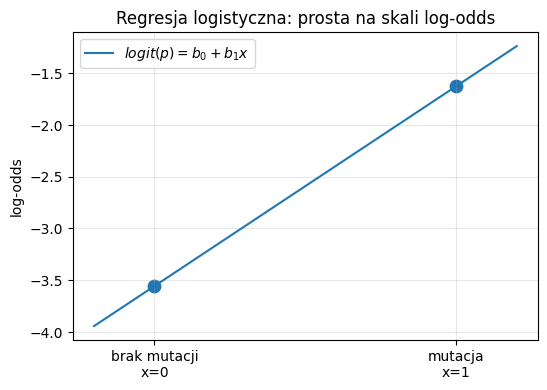

In [23]:
x_grid = np.linspace(-0.2, 1.2, 100)
log_odds_grid = b0 + b1 * x_grid

plt.figure(figsize=(6, 4))

plt.plot(x_grid, log_odds_grid, label=r"$logit(p)=b_0+b_1x$")
plt.scatter([0, 1], [log_odds_no_mutation, log_odds_mutation], s=80)

plt.xticks([0, 1], ["brak mutacji\nx=0", "mutacja\nx=1"])
plt.ylabel("log-odds")
plt.title("Regresja logistyczna: prosta na skali log-odds")
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

Na skali log-odds regresja logistyczna jest zwykłą prostą.

- punkt dla `x=0` to log-odds w grupie bez mutacji,
- punkt dla `x=1` to log-odds w grupie z mutacją,
- nachylenie prostej to:

$$
b_1=\log(OR)
$$

Po odlogarytmowaniu dostajemy:

$$
e^{b_1}=OR
$$

### Dopasowanie modelu ręcznie metodą Newtona/IRLS

In [24]:
def sigmoid(z):
    z = np.asarray(z, dtype=float)
    z = np.clip(z, -35, 35)
    return 1 / (1 + np.exp(-z))


def loglik_logistic(beta, X, y):
    eta = X @ beta
    return float(np.sum(y * eta - np.logaddexp(0, eta)))


def fit_logistic_irls(X, y, l2=0.0, max_iter=100, tol=1e-10):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    n, k = X.shape
    beta = np.zeros(k)
    penalty = np.eye(k)
    penalty[0, 0] = 0.0  # nie karzemy interceptu
    converged = False
    for iteration in range(max_iter):
        eta = X @ beta
        p = sigmoid(eta)
        W = p * (1 - p)
        gradient = X.T @ (y - p) - l2 * (penalty @ beta)
        information = (X.T * W) @ X + l2 * penalty
        step = np.linalg.pinv(information) @ gradient
        beta_new = beta + step
        if np.max(np.abs(step)) < tol:
            beta = beta_new
            converged = True
            break
        beta = beta_new
    eta = X @ beta
    p = sigmoid(eta)
    W = p * (1 - p)
    information = (X.T * W) @ X + l2 * penalty
    cov_beta = np.linalg.pinv(information)
    se_beta = np.sqrt(np.diag(cov_beta))
    ll = loglik_logistic(beta, X, y)
    return {
        'beta': beta,
        'se': se_beta,
        'cov': cov_beta,
        'll': ll,
        'converged': converged,
        'iterations': iteration + 1,
        'p_hat': p,
    }


def expand_2x2_counts(a, b, c, d):
    # Mutated=1: a cancer cases, b non-cases; Mutated=0: c cancer cases, d non-cases.
    rows = []
    rows += [{'mutated': 1, 'cancer': 1}] * int(a)
    rows += [{'mutated': 1, 'cancer': 0}] * int(b)
    rows += [{'mutated': 0, 'cancer': 1}] * int(c)
    rows += [{'mutated': 0, 'cancer': 0}] * int(d)
    return pd.DataFrame(rows)

expanded = expand_2x2_counts(a, b, c, d)
X_logit = np.column_stack([np.ones(len(expanded)), expanded['mutated'].to_numpy()])
y_logit = expanded['cancer'].to_numpy()
fit_logit_2x2 = fit_logistic_irls(X_logit, y_logit)
fit_logit_2x2['converged'], fit_logit_2x2['iterations']

(True, 8)

In [25]:
coef_table_logit = pd.DataFrame({
    'coef': fit_logit_2x2['beta'],
    'std_error': fit_logit_2x2['se'],
})
coef_table_logit['z'] = coef_table_logit['coef'] / coef_table_logit['std_error']
coef_table_logit['p_value_Wald'] = 2 * norm.sf(np.abs(coef_table_logit['z']))
coef_table_logit.index = ['intercept_log_odds_Mutated_No', 'log_OR_Mutated_Yes_vs_No']
coef_table_logit

,coef,std_error,z,p_value_Wald
intercept_log_odds_Mutated_No,-3.5553,0.4140,-8.587,8.9284e-18
log_OR_Mutated_Yes_vs_No,1.9287,0.4727,4.080,4.5029e-05


In [26]:
pd.Series({
    'beta_1_from_logistic_regression': fit_logit_2x2['beta'][1],
    'manual_log_OR': log_odds_ratio,
    'exp(beta_1)': math.exp(fit_logit_2x2['beta'][1]),
    'manual_OR': odds_ratio,
})

beta_1_from_logistic_regression    1.9287
manual_log_OR                      1.9287
exp(beta_1)                        6.8803
manual_OR                          6.8803
dtype: float64

### Probability i threshold w regresji logistycznej

Najpierw model logistyczny tworzy probability:

$$
p(x)=P(y=1 \mid x)
$$

Dopiero threshold zamienia probability na klasę 0/1.

ROC pokazuje, co się dzieje, gdy przesuwamy threshold.


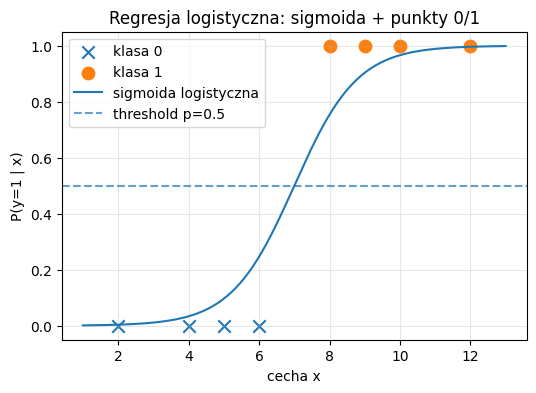

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Przykładowe dane 1D
X = np.array([[2], [4], [5], [6], [8], [9], [10], [12]])
y = np.array([0, 0, 0, 0, 1, 1, 1, 1])

# Model logistyczny
clf = LogisticRegression()
clf.fit(X, y)

# Siatka x do rysowania krzywej
x_grid = np.linspace(X.min() - 1, X.max() + 1, 300).reshape(-1, 1)
p_grid = clf.predict_proba(x_grid)[:, 1]

# Wykres
plt.figure(figsize=(6, 4))

# Punkty danych
plt.scatter(X[y == 0], y[y == 0], marker='x', s=80, label='klasa 0')
plt.scatter(X[y == 1], y[y == 1], marker='o', s=80, label='klasa 1')

# Krzywa logistyczna
plt.plot(x_grid, p_grid, label='sigmoida logistyczna')

# Threshold 0.5
plt.axhline(0.5, linestyle='--', alpha=0.7, label='threshold p=0.5')

plt.xlabel('cecha x')
plt.ylabel('P(y=1 | x)')
plt.title('Regresja logistyczna: sigmoida + punkty 0/1')
plt.ylim(-0.05, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 7. Mini-ćwiczenia

### Ćwiczenie A: odds zapisane jako sukcesy:porażki

Jeśli odds są zapisane jako `2:3`, to:

$$
odds=\frac{2}{3}\approx 0.667
$$

ale prawdopodobieństwo sukcesu wynosi:

$$
p_{prob}=\frac{2}{2+3}=\frac{2}{5}=0.4
$$

Jeśli odds są zapisane jako `3:5`, to:

$$
odds=\frac{3}{5}=0.6
$$

ale prawdopodobieństwo sukcesu wynosi:

$$
p_{prob}=\frac{3}{3+5}=\frac{3}{8}=0.375
$$

### Ćwiczenie B: odds i log-odds z prawdopodobieństwa

Jeśli $p_{prob}=0.8$, to:

$$
odds=\frac{0.8}{0.2}=4
$$

$$
log(odds)=\log(4)\approx 1.386
$$

### Ćwiczenie C: odds ratio

Dla tabeli:

$$
\begin{array}{c|cc}
 & Yes & No \\
\hline
Group A & 8 & 2 \\
Group B & 4 & 6
\end{array}
$$

$$
OR=\frac{8\cdot 6}{2\cdot 4}=6
$$

### Ćwiczenie D: interpretacja $\log(OR)$

Jeśli $\log(OR)=0$, to $OR=1$, czyli brak różnicy odds między grupami.


## 8. Checklista prowadzącego

Po tym notebooku student powinien umieć:

1. Odróżnić `p_prob` jako prawdopodobieństwo od `p_value` jako wyniku testu statystycznego.
2. Przeliczyć $p_{prob} \leftrightarrow odds \leftrightarrow log(odds)$.
3. Odczytać odds zapisane jako `sukcesy:porażki`, np. `2:3` albo `3:5`.
4. Policzyć $OR = ad/bc$ dla tabeli 2×2.
5. Wyjaśnić, dlaczego $\log(OR)$ jest naturalny w regresji logistycznej.
6. Ręcznie policzyć oczekiwane liczebności w teście chi-square.
7. Wyjaśnić, że Fisher liczy prawdopodobieństwa tabel przy ustalonych marginesach.
8. Policzyć test Walda dla $\log(OR)$.
